In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Read Data
# ==========================================
df_tess_k = pd.read_csv('tesseract_kleister.csv')
df_docl_k = pd.read_csv('docling_kleister.csv')
# UPDATED: Use the new deepseek file for Kleister
df_deep_k = pd.read_csv('deepseek_kleister_bs5.csv')

df_tess_v = pd.read_csv('tesseract_vrdu.csv')
df_docl_v = pd.read_csv('docling_vrdu.csv')
# UPDATED: Use the new deepseek file for VRDU
df_deep_v = pd.read_csv('deepseek_vrdu_report_bs10.csv')

# ==========================================
# 2. Extract and Calculate Values (in Wh)
# ==========================================
# --- Kleister Total & Per Page ---
tess_k_wh_total = float(df_tess_k[df_tess_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_tess_k = float(df_tess_k[df_tess_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
tess_k_wh_per_page = tess_k_wh_total / pages_tess_k

docl_k_wh_total = float(df_docl_k[df_docl_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_docl_k = float(df_docl_k[df_docl_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
docl_k_wh_per_page = docl_k_wh_total / pages_docl_k

# UPDATED: DeepSeek Kleister Calculation using the new Metric/Value layout
deep_k_wh_total = float(df_deep_k[df_deep_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_deep_k = float(df_deep_k[df_deep_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
deep_k_wh_per_page = deep_k_wh_total / pages_deep_k

# --- VRDU Total & Per Page ---
tess_v_wh_total = float(df_tess_v['Total Energy Consumed (kWh)'].iloc[0]) * 1000
pages_tess_v = float(df_tess_v['Total Pages Processed'].iloc[0])
tess_v_wh_per_page = tess_v_wh_total / pages_tess_v

docl_v_wh_total = float(df_docl_v[df_docl_v['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_docl_v = float(df_docl_v[df_docl_v['Metric'] == 'Total Pages Processed']['Value'].values[0])
docl_v_wh_per_page = docl_v_wh_total / pages_docl_v

# UPDATED: DeepSeek VRDU Calculation using the new Metric/Value layout
deep_v_wh_total = float(df_deep_v[df_deep_v['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_deep_v = float(df_deep_v[df_deep_v['Metric'] == 'Total Pages Processed']['Value'].values[0])
deep_v_wh_per_page = deep_v_wh_total / pages_deep_v

# ==========================================
# 3. Plotting Setup
# ==========================================
labels = ['Tesseract', 'Docling', 'DeepSeek']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Calculate Min/Max bounds to share the axes properly
total_k = [tess_k_wh_total, docl_k_wh_total, deep_k_wh_total]
total_v = [tess_v_wh_total, docl_v_wh_total, deep_v_wh_total]
max_total = max(max(total_k), max(total_v)) * 1.15
min_total = 0 # Linear scale usually starts at 0

per_page_k = [tess_k_wh_per_page, docl_k_wh_per_page, deep_k_wh_per_page]
per_page_v = [tess_v_wh_per_page, docl_v_wh_per_page, deep_v_wh_per_page]
max_per_page = max(max(per_page_k), max(per_page_v)) * 3
min_per_page = min(min(per_page_k), min(per_page_v)) * 0.5

def add_labels(ax, values, f_size=8):
    for i, v in enumerate(values):
        # Format highly precise decimals for the tiny values so they show up as text
        label_text = f'{v:.4f} Wh' if v < 0.1 else f'{v:.2f} Wh'
        ax.annotate(label_text,
                    xy=(i, v),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=f_size, fontweight='bold')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 300
})

# ------------------------------------------
# Plot 1: Total Energy (ACL Single Column Layout)
# ------------------------------------------
fig1, axes1 = plt.subplots(2, 1, figsize=(3.1, 5.0))

axes1[0].bar(labels, total_k, color=colors, edgecolor='black')
axes1[0].set_title('Kleister: Total Energy (500 Docs)', fontsize=10)
axes1[0].set_ylabel('Energy (Wh)', fontsize=9)
axes1[0].set_ylim(min_total, max_total)
axes1[0].grid(axis='y', linestyle='--', alpha=0.7)
axes1[0].tick_params(axis='both', which='major', labelsize=8)
add_labels(axes1[0], total_k, f_size=8)

axes1[1].bar(labels, total_v, color=colors, edgecolor='black')
axes1[1].set_title('VRDU: Total Energy (500 Docs)', fontsize=10)
axes1[1].set_ylabel('Energy (Wh)', fontsize=9)
axes1[1].set_ylim(min_total, max_total)
axes1[1].grid(axis='y', linestyle='--', alpha=0.7)
axes1[1].tick_params(axis='both', which='major', labelsize=8)
add_labels(axes1[1], total_v, f_size=8)

fig1.tight_layout()
fig1.savefig('total_energy_comparison.pdf', format='pdf', bbox_inches='tight')

# ------------------------------------------
# Plot 2: Per Page Energy (ACL Single Column Layout)
# ------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(3.1, 5.0))

axes2[0].bar(labels, per_page_k, color=colors, edgecolor='black')
axes2[0].set_title('Kleister: Energy Per Page', fontsize=10)
axes2[0].set_ylabel('Energy (Wh) - Log', fontsize=9)
axes2[0].set_yscale('log')
axes2[0].set_ylim(min_per_page, max_per_page)
axes2[0].grid(axis='y', linestyle='--', alpha=0.7)
axes2[0].tick_params(axis='both', which='major', labelsize=8)
add_labels(axes2[0], per_page_k, f_size=8)

axes2[1].bar(labels, per_page_v, color=colors, edgecolor='black')
axes2[1].set_title('VRDU: Energy Per Page', fontsize=10)
axes2[1].set_ylabel('Energy (Wh) - Log', fontsize=9)
axes2[1].set_yscale('log')
axes2[1].set_ylim(min_per_page, max_per_page)
axes2[1].grid(axis='y', linestyle='--', alpha=0.7)
axes2[1].tick_params(axis='both', which='major', labelsize=8)
add_labels(axes2[1], per_page_v, f_size=8)

fig2.tight_layout()
fig2.savefig('per_page_energy_comparison.pdf', format='pdf', bbox_inches='tight')

# Show both figures
plt.show()

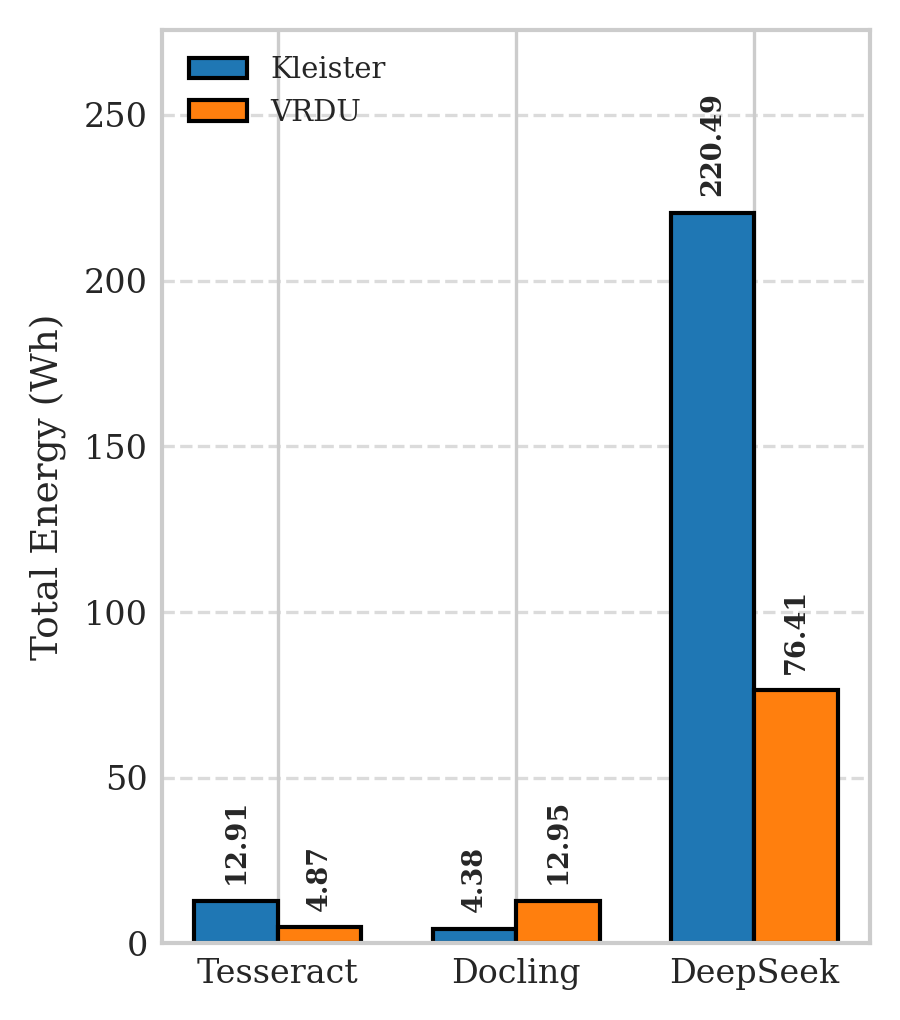

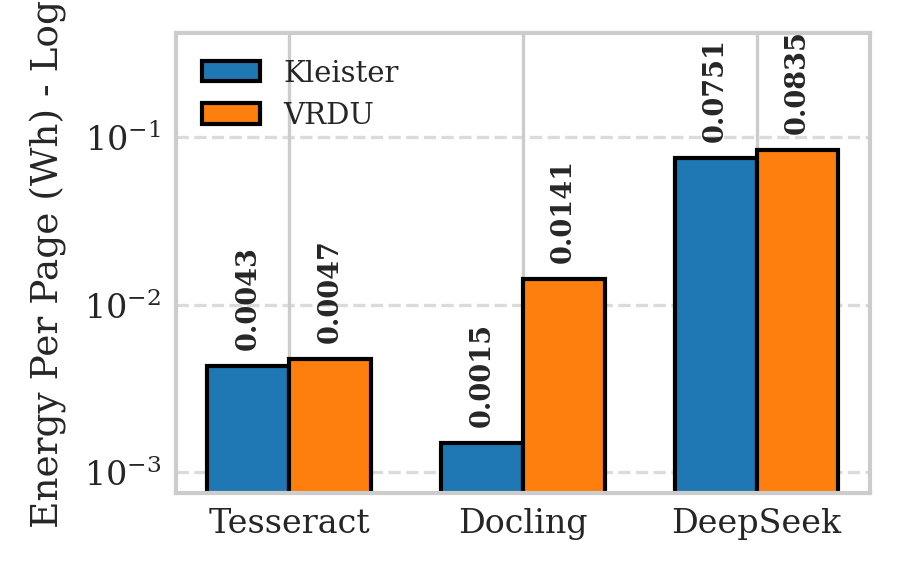

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Read Data
# ==========================================
df_tess_k = pd.read_csv('tesseract_kleister.csv')
df_docl_k = pd.read_csv('docling_kleister.csv')
df_deep_k = pd.read_csv('deepseek_kleister_bs5.csv')

df_tess_v = pd.read_csv('tesseract_vrdu.csv')
df_docl_v = pd.read_csv('docling_vrdu.csv')
df_deep_v = pd.read_csv('deepseek_vrdu_report_bs10.csv')

# ==========================================
# 2. Extract and Calculate Values (in Wh)
# ==========================================
# --- Kleister Total & Per Page ---
tess_k_wh_total = float(df_tess_k[df_tess_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_tess_k = float(df_tess_k[df_tess_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
tess_k_wh_per_page = tess_k_wh_total / pages_tess_k

docl_k_wh_total = float(df_docl_k[df_docl_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_docl_k = float(df_docl_k[df_docl_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
docl_k_wh_per_page = docl_k_wh_total / pages_docl_k

deep_k_wh_total = float(df_deep_k[df_deep_k['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_deep_k = float(df_deep_k[df_deep_k['Metric'] == 'Total Pages Processed']['Value'].values[0])
deep_k_wh_per_page = deep_k_wh_total / pages_deep_k

# --- VRDU Total & Per Page ---
tess_v_wh_total = float(df_tess_v['Total Energy Consumed (kWh)'].iloc[0]) * 1000
pages_tess_v = float(df_tess_v['Total Pages Processed'].iloc[0])
tess_v_wh_per_page = tess_v_wh_total / pages_tess_v

docl_v_wh_total = float(df_docl_v[df_docl_v['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_docl_v = float(df_docl_v[df_docl_v['Metric'] == 'Total Pages Processed']['Value'].values[0])
docl_v_wh_per_page = docl_v_wh_total / pages_docl_v

deep_v_wh_total = float(df_deep_v[df_deep_v['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
pages_deep_v = float(df_deep_v[df_deep_v['Metric'] == 'Total Pages Processed']['Value'].values[0])
deep_v_wh_per_page = deep_v_wh_total / pages_deep_v

# ==========================================
# 3. Plotting Setup (Grouped Bar Charts)
# ==========================================
labels = ['Tesseract', 'Docling', 'DeepSeek']
x = np.arange(len(labels))
width = 0.35  # Width of the bars

total_k = [tess_k_wh_total, docl_k_wh_total, deep_k_wh_total]
total_v = [tess_v_wh_total, docl_v_wh_total, deep_v_wh_total]
max_total = max(max(total_k), max(total_v)) * 1.25
min_total = 0

per_page_k = [tess_k_wh_per_page, docl_k_wh_per_page, deep_k_wh_per_page]
per_page_v = [tess_v_wh_per_page, docl_v_wh_per_page, deep_v_wh_per_page]
max_per_page = max(max(per_page_k), max(per_page_v)) * 5 # Extra overhead for log scale labels
min_per_page = min(min(per_page_k), min(per_page_v)) * 0.5

# Helper function for grouped bar annotations
def add_bar_labels(ax, rects, f_size=6.5):
    for rect in rects:
        height = rect.get_height()
        # Formatting: 4 decimals for tiny values, 2 for larger. Removed 'Wh' to save space.
        label_text = f'{height:.4f}' if height < 0.1 else f'{height:.2f}'
        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=f_size, fontweight='bold', rotation=90) # Rotated to prevent overlap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 300
})

# ------------------------------------------
# Plot 1: Total Energy Combined (ACL Single Column)
# ------------------------------------------
fig1, ax1 = plt.subplots(figsize=(3.1, 3.5))

rects1_k = ax1.bar(x - width/2, total_k, width, label='Kleister', color='#1f77b4', edgecolor='black')
rects1_v = ax1.bar(x + width/2, total_v, width, label='VRDU', color='#ff7f0e', edgecolor='black')

ax1.set_ylabel('Total Energy (Wh)', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylim(min_total, max_total)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='y', which='major', labelsize=8)
ax1.legend(fontsize=7, loc='upper left')

add_bar_labels(ax1, rects1_k)
add_bar_labels(ax1, rects1_v)

fig1.tight_layout()
fig1.savefig('total_energy_combined.pdf', format='pdf', bbox_inches='tight')

# ------------------------------------------
# Plot 2: Per Page Energy Combined (ACL Single Column)
# ------------------------------------------
fig2, ax2 = plt.subplots(figsize=(3.1, 2))

rects2_k = ax2.bar(x - width/2, per_page_k, width, label='Kleister', color='#1f77b4', edgecolor='black')
rects2_v = ax2.bar(x + width/2, per_page_v, width, label='VRDU', color='#ff7f0e', edgecolor='black')

ax2.set_ylabel('Energy Per Page (Wh) - Log', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_yscale('log')
ax2.set_ylim(min_per_page, max_per_page)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', which='major', labelsize=8)
ax2.legend(fontsize=7, loc='upper left')

add_bar_labels(ax2, rects2_k)
add_bar_labels(ax2, rects2_v)

fig2.tight_layout()
fig2.savefig('per_page_energy_combined.pdf', format='pdf', bbox_inches='tight')

# Show both figures
plt.show()